In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.interpolate as interp
import scipy.integrate as integ
import scipy.special as sc
import scipy.signal as sig
import h5py as h5
import os.path
import matplotlib.ticker
from matplotlib import cm
from numba import njit

plt.rc('figure', figsize=(12, 9))
plt.rcParams.update({'text.usetex': True,
                     'font.family': 'serif',
                     'font.serif': ['Georgia'],
                     'mathtext.fontset': 'cm',
                     'lines.linewidth': 2.5,
                     'font.size': 20,
                     'xtick.labelsize': 'large',
                     'ytick.labelsize': 'large',
                     'xtick.direction': 'in',
                     'ytick.direction': 'in',
                     'xtick.major.width': 1.7,
                     'ytick.major.width': 1.7,
                     'xtick.major.size': 7.,
                     'ytick.major.size': 7.,
                     'ytick.right':True, 
                     'axes.labelsize': 'large',
                     'axes.titlesize': 'large',
                     'axes.grid': False,
                     'grid.alpha': 0.5,
                     'lines.markersize': 12,
                     'legend.borderpad': 0.2,
                     'legend.fancybox': True,
                     'legend.fontsize': 19.5,
                     'legend.framealpha': 0.7,
                     'legend.handletextpad': 0.5,
                     'legend.labelspacing': 0.2,
                     'legend.loc': 'best',
                     'savefig.bbox': 'tight',
                     'savefig.pad_inches': 0.05,
                     'savefig.dpi': 80,
                     'pdf.compression': 9})



G=6.67259e-8
c=2.99792458e10
Ms=1.989e33

sqrt2=np.sqrt(2)
sqrt3=np.sqrt(3)
sqrt5=np.sqrt(5)
sqrt6=np.sqrt(6)

W22 = np.sqrt(3*np.pi/10)
W20 = -np.sqrt(np.pi/5)
W00 = np.sqrt(4*np.pi)

Ytens22 = np.sqrt(15/32/np.pi) * np.array([[1, -1j, 0], [-1j, -1, 0], [0, 0, 0]])
Ytens2n = np.conj(Ytens22)
Ytens20 = -np.sqrt(5/16/np.pi) * np.array([[1, 0, 0], [0, 1, 0], [0, 0, -2]])

# functions defining the equations of motion

In [2]:
@njit
def get_tot_pot(yV, par):
    """
    total potential energy of the system
    """
    q2, q0, qn, qr = yV[:4]
    al = yV[-1]
    
    M1, R1,\
    wfnatsq, wrnatsq,\
    If, Ir, Kr,\
    k2, k2r, krr, J2, J2r,\
    z2, z20r, z2r, zrr, \
    gamf_GW, gam2, gam0, gamr,\
    dadt\
        = par

    # the coupling coefficients in par assumes the pressure is given by the virial theorem
    # this is not needed
    # cf. eqs. 4.25 and 4.26 of https://articles.adsabs.harvard.edu/pdf/1983A%26A...121...97C
    # corrections from al
    _k2 = k2 * (38+35 * al)/38
    _k2r = k2r * (3*(4+5*al)*wfnatsq + 4*(1+al)*wrnatsq)/(12*wfnatsq + 4*wrnatsq)
    _krr = krr * (75*al*wfnatsq*wfnatsq + 50*(1+al)*wfnatsq*wrnatsq + 8*(1+al)*wrnatsq*wrnatsq)\
        /(50*wfnatsq*wrnatsq+8*wrnatsq*wrnatsq)
    
    _z2 = z2 * ((67+70*al)*wfnatsq + 14*(1+al)*wrnatsq)/(67*wfnatsq + 14*wrnatsq)
    _z20r = z20r * ((38+35*al)*wfnatsq + 7*(1+al)*wrnatsq)/(38*wfnatsq + 7*wrnatsq)
    _z2r = z2r \
        * (15*(4+5*al)*wfnatsq*wfnatsq + 35*(1+al)*wfnatsq*wrnatsq + 4*(1+al)*wrnatsq*wrnatsq)\
        / (60*wfnatsq*wfnatsq + 35*wfnatsq*wrnatsq + 4*wrnatsq*wrnatsq)
    _zrr = zrr \
        * (375*wfnatsq**3 - (1+al)*(5*wfnatsq+wrnatsq)*(75*wfnatsq*wfnatsq+50*wfnatsq*wrnatsq+8*wrnatsq*wrnatsq) )\
        / (375*wfnatsq**3 - (5*wfnatsq+wrnatsq)*(75*wfnatsq*wfnatsq+50*wfnatsq*wrnatsq+8*wrnatsq*wrnatsq))

    # other spherical combos
    _k0 = - _k2
    _k0r = _k2r

    _z20 = 0.5 * _z2  # (2,-2,0,0)
    _z0 = 1.5 * _z2   # (0,0,0,0)
    _z00r = -_z20r # (0,0,0,r)
    _z0r = _z2r # (0,0,r,r)

    # total potential truncated at 4-wave order
    Utot1 = Kr * al * qr 
    Utot2 = 0.125*((4+5*al)*(q0*q0 + 2*q2*qn) + 2*(2+al*(2+5*wfnatsq/wrnatsq))*qr**2)
    Utot3 = - 1/3 * (\
        6*_k2*q2*q0*qn + _k0*q0**3 \
        + 6*_k2r*q2*qr*qn \
        + 3*_k0r*q0**2*qr + _krr*qr**3\
    )
    Utot4 = - 1/4 *(\
        6*_z2*q2**2*qn**2 + 12*_z20*q2*qn*q0**2+ _z0*q0**4\
      + 24*_z20r*q2*qn*q0*qr + 4*_z00r*q0**3*qr\
      + 12*_z2r*q2*qn*qr**2 + 6*_z0r*q0**2*qr**2\
      + _zrr*qr**4
    )

    Utot = (Utot1 + Utot2 + Utot3 + Utot4)*M1**2/R1

    return Utot

def EOMs(tt, yV, par):
    """
    Equations of motion from the Lagrangian.
    Todo: 
         self-consistent evolution of the specific entropy ~ al due to dissipation
    """
    
    q2, q0, qn, qr, dq2, dq0, dqn, dqr, al = yV
    
    M1, R1,\
    wfnatsq, wrnatsq,\
    If, Ir, Kr,\
    k2, k2r, krr, J2, J2r,\
    z2, z20r, z2r, zrr, \
    gamf_GW, gam2, gam0, gamr,\
    dadt\
        = par

    E1 = M1**2/R1
    w1sq = M1/R1**3
    wfsq = wfnatsq * w1sq
    wrsq = wrnatsq * w1sq

    dyV = np.zeros(9, dtype=np.complex128)

    #
    dyV[0] = dq2
    dyV[1] = dq0
    dyV[2] = dqn
    dyV[3] = dqr

    # conservative forces from Lagrangian
    pLpq2 = -complex_step_diff(get_tot_pot, yV, par, 0)/E1
    pLpq0 = -complex_step_diff(get_tot_pot, yV, par, 1)/E1
    pLpqn = -complex_step_diff(get_tot_pot, yV, par, 2)/E1
    pLpqr = -complex_step_diff(get_tot_pot, yV, par, 3)/E1

    # ddq; 

    # NL enhancement by matching to 1/5 * \dddot{Q}_ij * \dddot{Q}_ij
    gam2_GW_factor = (1 + 2 * J2r/If * qr + 3 * J2/If * q0)
    gam0_GW_factor = (1 + 2 * J2r/If * qr - J2/If * q0)
    
    dyV[4] = wfsq * pLpqn - 2 * (gamf_GW * gam2_GW_factor + gam2) * dq2
    dyV[5] = wfsq * pLpq0 - 2 * (gamf_GW * gam0_GW_factor + gam0) * dq0
    dyV[6] = wfsq * pLpq2 - 2 * (gamf_GW * gam2_GW_factor + gam2) * dqn
    dyV[7] = wrsq * pLpqr - 2 * gamr * dqr

    # specific entropy evolution
    # should be self-consistent with fluid dissipation
    # right now just prescribed by a linear evolution
    dyV[8] = dadt
    return dyV    

def complex_step_diff(func, yV, par, idx, hh = 1e-10):
    yV_v = yV.copy()
    yV_v[idx] += 1j*hh

    # df = np.imag(func(yV_v, par))/hh
    df = (func(yV_v, par) - func(yV, par))/(1j*hh)
    return df       

# background star 

In [3]:
### n=1

M1_phy = 2*1.35 * Ms
R1_phy = 11.7e5

nn = 1
Gamma = 2
Mast = 0.1306910
sqrtMast = np.sqrt(Mast)


### n=0.5

# M1_phy = 2*1.35 * Ms
# # K ~ R^[(3-n)/n] M^[(n-1)/n] ~ const
# R1_phy = 11.7e5 * 2**0.2

# nn = 0.5 
# Gamma = 1 + 1/nn
# Mast = 0.1629656
# sqrtMast = np.sqrt(Mast)



###
rM1 = G*M1_phy/c**2
tM1 = rM1/c
M1 = 1
R1 = R1_phy/rM1

E1 = M1**2/R1
w1sq = M1/R1**3
w1 = np.sqrt(M1/R1**3)

CC = M1/R1
print(CC)

0.3407734255622972


In [4]:
dadt = 0

# fluid dissipation; empirically set
# todo: should use gam_nl = gam_nl_coeff * |q|**2 for nonlinear dissipations
gam2wf = 2e-3 
gam0wf = 1e-2 
gamrwr = 3e-2 


# Newtonian
wf_N = np.sqrt(4/5/(5-nn)/Mast * M1/R1**3)
wr_N = wf_N * np.sqrt((3*Gamma-4) * 5/4)

wfnatsq_N = wf_N**2 / w1sq
wrnatsq_N = wr_N**2 / w1sq

print(f'Newtonian omegaf/2/pi = {wf_N/tM1/2/np.pi:.1f}, omegar/2/pi = {wr_N/tM1/2/np.pi:.1f}')

Ia_N = np.sqrt(15*Mast/2/np.pi) * w1/wf_N
Ir_N = np.sqrt(0.1) * wf_N/wr_N * Ia_N
print(f'If={Ia_N:0.3f}, Ir={Ir_N:0.3f}')

# how the equilibrium background radius changes when entropy evolves
Kr_N = -np.sqrt(5*np.pi/8) * Ia_N * wf_N/wr_N * wfnatsq_N


k2_N = -19/28 * np.sqrt(5/np.pi) / wfnatsq_N / Ia_N
J2_N = -1/2 * np.sqrt(5/np.pi) / wfnatsq_N
print(f'k2={k2_N:0.3f}, J2={J2_N:0.3f}')

k2r_N = np.sqrt(5/8/np.pi)/Ia_N * (3*w1sq/wf_N/wr_N + w1sq*wr_N/wf_N**3)
krr_N = 1/2/np.sqrt(10*np.pi)/Ia_N * (25*w1sq/wf_N/wr_N + 4*w1sq*wr_N/wf_N**3)
J2r_N = np.sqrt(5/2/np.pi) * w1sq/wf_N/wr_N

z2_N = - 5*(67+14*wrnatsq_N/wfnatsq_N)/(84 * np.pi * Ia_N**2 * wfnatsq_N**2)
z20r_N = 5*(38*wf_N**2 + 7*wr_N**2)*w1sq*w1sq/(42*sqrt2*np.pi*Ia_N**2*wf_N**5*wr_N)
z2r_N = -(60*wf_N**4 + 35*wf_N**2*wr_N**2 + 4*wr_N**4)*w1sq*w1sq/(12*np.pi*Ia_N**2*wf_N**6*wr_N**2)
zrr_N = -(325*wf_N**4 + 90*wf_N**2*wr_N**2 + 8*wr_N**4)*w1sq*w1sq/(30*Ia_N**2*np.pi*wf_N**6*wr_N**2)

love2_N = 2*np.pi/5 * Ia_N**2
ddk2_N = love2_N / wfnatsq_N
p2_N = 2 * np.pi/5 * W20 * Ia_N**2 * (3*J2_N + 2*k2_N*Ia_N)
print(love2_N, ddk2_N, p2_N)


gam2_GW_N = 4 * np.pi/75 * wf_N * (wf_N * R1)**5 * Ia_N**2  
print(gam2_GW_N, gam2_GW_N/wf_N)

par_N = np.array([
    M1, R1,\
    wfnatsq_N, wrnatsq_N,\
    Ia_N, Ir_N, Kr_N,\
    k2_N, k2r_N, krr_N, J2_N, J2r_N,\
    z2_N, z20r_N, z2r_N, zrr_N, \
    gam2_GW_N, gam2wf * wf_N, gam0wf * wf_N, gamrwr * wr_N,\
    dadt])


# GR

### n = 1

love2 = 0.0556 / 2 # assuming love number ~ 1/M to give 1/M^6 in Lambda 
love2_tilde = love2 * np.exp(2.4 * CC)

ddk2_fudge = 1.
ddk2 = np.sqrt( (1.7 + 0.76 * love2_tilde**0.73 - 0.2 * love2_tilde**(-0.27)) * love2_tilde**3 )  * ddk2_fudge

p2 = 20/7 * ddk2 * np.exp(-4*CC)
print(f'ddk2={ddk2:0.3f}, p2={p2:0.3f}')
love2_N = 0.260
ddk2_N = 0.1726
p2_N = 0.495



# ### n = 0.5

# love2 = 0.025
# p2 = 0.0057
# ddk2 = 7/20 * p2 * np.exp(4*CC)

# p2 = 0.0057
# ddk2 = 7/20 * p2 * np.exp(4*CC)
# print(f'ddk2={ddk2:0.3f}, p2={p2:0.3f}')
# love2_N = 0.45
# p2_N = 1.18
# ddk2_N = 7/20 * p2_N



###

Lam = 2/3*love2*R1**5
Ia = np.sqrt(5 * love2/(2*np.pi))
wf = w1 * np.sqrt(love2/ddk2)
wr = wr_N * wf/wf_N
Ir = Ir_N * Ia/Ia_N

print(f'GR omegaf/2/pi = {wf/tM1/2/np.pi:.1f}, omegar/2/pi = {wr/tM1/2/np.pi:.1f}')

# unconstrained
Kr = Kr_N

wfnatsq = wf*wf/w1sq
wrnatsq = wr*wr/w1sq


k2 = p2/(-2*np.pi/5 * np.sqrt(np.pi/5) * Ia**2) * (2*k2_N*Ia_N)/(2*k2_N*Ia_N + 3*J2_N) / 2 / Ia 
J2 = p2/(-2*np.pi/5 * np.sqrt(np.pi/5) * Ia**2) * (3*J2_N)/(2*k2_N*Ia_N + 3*J2_N) / 3

k2r = k2r_N * k2/k2_N 
krr = krr_N * k2/k2_N 
J2r = J2r_N * J2/J2_N

z2 = z2_N * np.exp(-3 * M1/R1) #* Ia_N**2 * omegaf_N**4 / Ia**2 / omegaf**4
z20r = z20r_N * np.exp(-3 * M1/R1) #* z2/z2_N
z2r = z2r_N * np.exp(-3 * M1/R1) #* z2/z2_N
zrr = zrr_N * np.exp(-3 * M1/R1) #* z2/z2_N

# GW dissipation
gam2_GW_fudge = 1.5 # Ia ~ \sqrt{k2} has uncertainty

# this is from matching the damping time to what the quadrupole formula predicts
gam2_GW = 4 * np.pi/75 * wf * (wf * R1)**5 * Ia**2 * gam2_GW_fudge
print(f'damping gamma/wf={gam2_GW/wf:.2e}, time tau = 1/gamma = {tM1/gam2_GW:.2f} s')


par_G = np.array([
    M1, R1,\
    wfnatsq, wrnatsq,\
    Ia, Ir, Kr,\
    k2, k2r, krr, J2, J2r,\
    z2, z20r, z2r, zrr, \
    gam2_GW, gam2wf * wf, gam0wf * wf, gamrwr * wr,\
    dadt])

Newtonian omegaf/2/pi = 2945.0, omegar/2/pi = 4656.4
If=0.452, Ir=0.090
k2=-1.239, J2=-0.412
0.25620206221499997 0.16741651856470277 0.4783329101848651
0.0016509623959221243 0.0067088247026311255
ddk2=0.019, p2=0.014
GR omegaf/2/pi = 2913.3, omegar/2/pi = 4606.4
damping gamma/wf=1.03e-03, time tau = 1/gamma = 0.05 s


# initial conditions

In [12]:
# matching angular momentum
M10 = 0.5
Mt = M1

M20 = Mt - M10
mu = M10 * M20/Mt

# Keplerian estimate; should be replaced by the EOB model
JJ_orb = mu * np.sqrt(Mt * 2 * R1) 

# orbital AM pre-merger goes into the AM of the PMO 
q2_mag = np.sqrt(0.25*JJ_orb/E1*wf) 
print(f'expected amplitude of q2 mode: {q2_mag:.2f}')

# order unity fudge factor
q2_fudge = 0.7

# initial phase unconstrained
q2 = q2_mag * np.exp(-1j*np.pi/3) * q2_fudge
qn = np.conj(q2)
dq2 = -1j*wf*q2
dqn = np.conj(dq2)

# energy?
# premerger: 
# orbital + each star's binding 
# todo: include tidal interaction and mode energies
Eorb = -0.5 * mu * Mt/2./R1
E10 = (-3/(5-nn) + 1/(5-nn)/(Gamma-1)) * M10**2/R1
E20 = (-3/(5-nn) + 1/(5-nn)/(Gamma-1)) * M20**2/R1

# post-merger
# background binding + perturbations in modes (m=2 and radial)
E11 = (-3/(5-nn) + 1/(5-nn)/(Gamma-1)) * M1**2/R1
Eq2 = E1 * np.real(q2*qn + dq2*dqn/wf**2)
Eqr = Eorb+E10+E20-E11-Eq2
print(f'expected amplitude of energy of the radial mode: {Eqr/E1:.2f}')

###

# initial conditions for m=0 and radial modes have large uncertainties 
# transient term from energy + forced term from NL |m|=2 modes' drive
# for now just start with zero; 
# this will excite oscillations at their natural frequencies
q0 = np.real(np.sqrt(Eqr) +  2*k2*q2*qn) * 0
qr = np.real( 2*k2r*q2*qn ) * 0

dq0 = np.real(-1j*wf*q0)
dqr = np.real(-1j*wr*qr)

al = 0

yV_init = np.array([q2, q0, qn, qr, 
                    dq2, dq0, dqn, dqr, 
                    al])

expected amplitude of q2 mode: 0.33
expected amplitude of energy of the radial mode: 0.08


In [13]:
sol_G = integ.solve_ivp(EOMs, (0, 2*np.pi*34/wf), yV_init, 
                      args=(par_G,), atol=1e-9, rtol=1e-9)

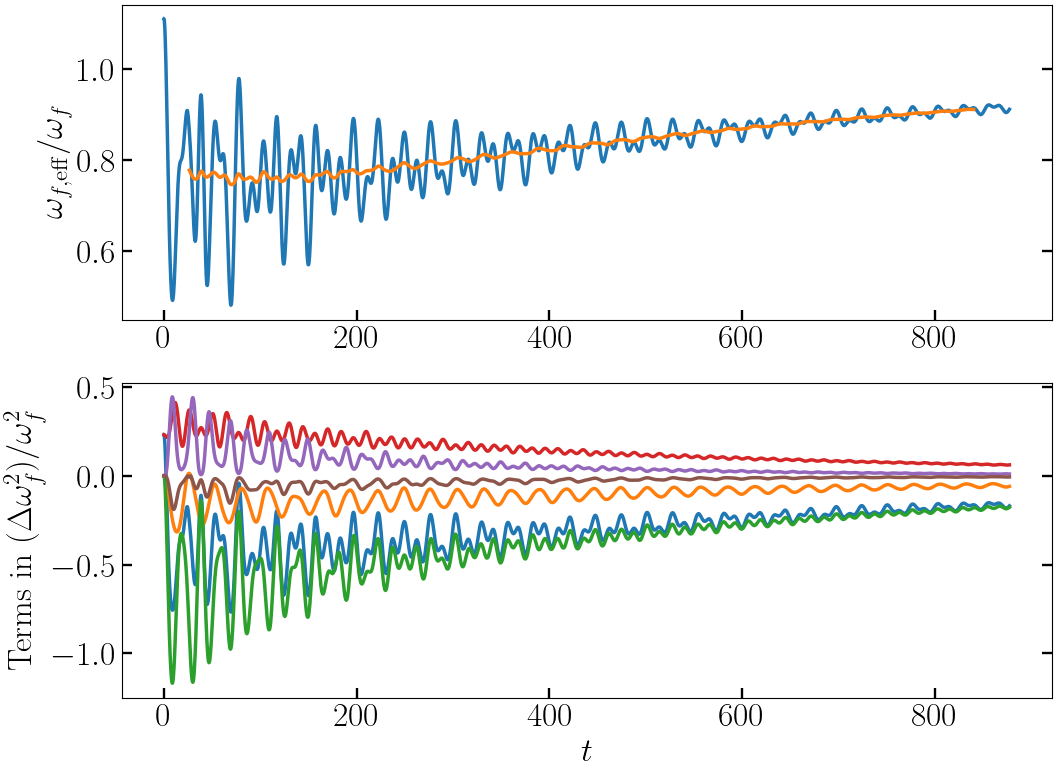

In [14]:
tt=sol_G.t
q2, q0, qn, qr, \
dq2, dq0, dqn, dqr, \
al = sol_G.y[:]

# when heat is generated, how the background radius should evolve from theoretical calc
qreq = np.real(5*np.sqrt(3*Mast)*al*wf*wf/(4*wr*w1))


# effective mode frequency
# using logics similar to the derivation of eq. 96 in 2607.07943
# but does not replace q0 and qr by their equilibrium solutions (hence no k2^2 terms)
# corrected pre-factors for a configuration space description
dlogwfsq = - 2 * k2 * q0.real - 2 * k2r * qr.real \
            - 3 * z2 * np.abs(q2)**2 - 3 * 0.5*z2 * np.abs(q0)**2 - 3 * z2r * np.abs(qr)**2\
            - 6 * z20r * np.abs(q0 * qr)
wf_eff = wf*np.sqrt(1 + dlogwfsq)
# wf_eff = wf*(1+0.5*dlogwfsq)

# simple moving average
window_size = 180
weights = np.ones(window_size) / window_size
wf_eff_lp = np.convolve(wf_eff, weights, mode='valid')


fig=plt.figure()
ax=fig.add_subplot(211)
# ax.plot(tt, (1+dlogwf))
ax.plot(tt, wf_eff/wf)
ax.plot(tt[window_size//2:-window_size//2], wf_eff_lp[1:]/wf)
ax.set_ylabel(r'$\omega_{f, {\rm eff}}/\omega_f$')

ax=fig.add_subplot(212)
ax.plot(tt, dlogwfsq)
ax.plot(tt, - 2 * k2 * q0.real)
ax.plot(tt, - 2 * k2r * qr.real)
ax.plot(tt, - 3 * z2 * np.abs(q2)**2)
ax.plot(tt, - 3 * z2r * np.abs(qr)**2)
ax.plot(tt, - 6 * z20r * np.abs(q0 * qr))
ax.set_ylabel(r'Terms in $(\Delta \omega_f^2)/\omega_f^2$')
ax.set_xlabel(r'$t$')

plt.show()


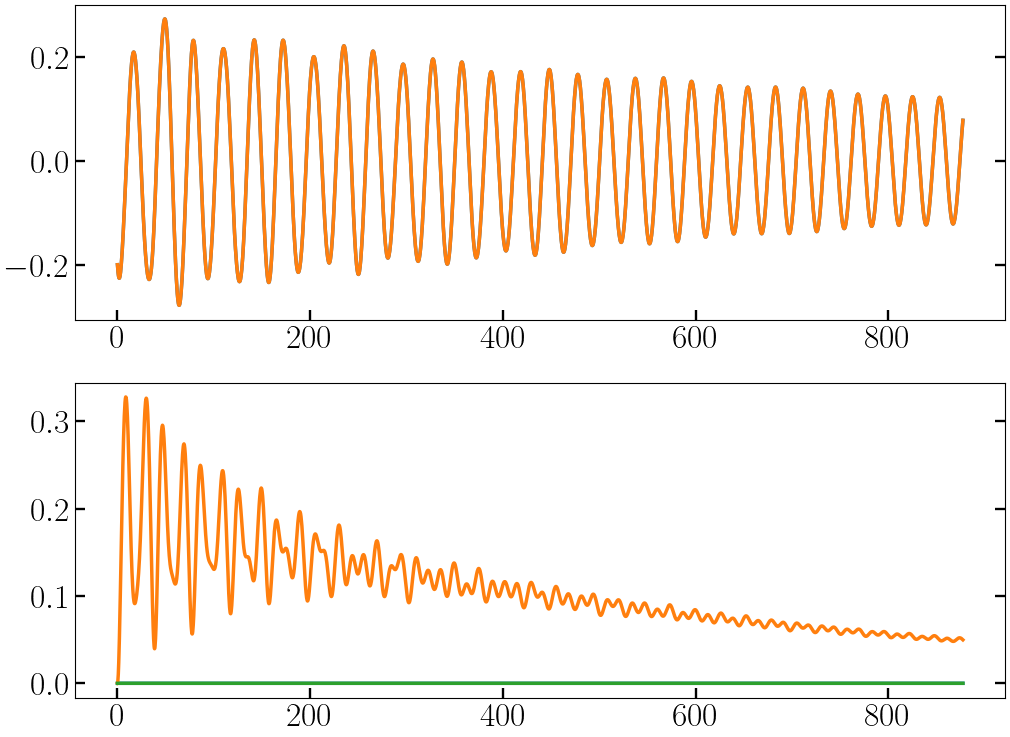

In [15]:
# checking mode amplitudes in time domain

fig=plt.figure()
ax=fig.add_subplot(211)
# ax.plot(tt, np.real(q2*np.exp(1j*wf*tt)))
# ax.plot(tt, np.real(qn*np.exp(-1j*wf*tt)))

ax.plot(tt, np.imag(q2))
ax.plot(tt, -np.imag(qn))


ax=fig.add_subplot(212)
ax.plot(tt, qreq)
ax.plot(tt, np.real( qr ))
ax.plot(tt, np.imag(qr))
# ax.plot(tt, np.real(qr*np.exp(1j*wr*tt)))
plt.show()

In [16]:
# change time to seconds
t_phy=tt*tM1
print(t_phy[-1])

win = sig.windows.tukey(len(tt), alpha=0.5)


Req2_vs_t = interp.CubicSpline(t_phy, win*np.real(q2), extrapolate=False)
Req0_vs_t = interp.CubicSpline(t_phy, win*sig.detrend(np.real(q0)), extrapolate=False)
Reqr_vs_t = interp.CubicSpline(t_phy, win*sig.detrend(np.real(qr)), extrapolate=False)


fs_phy = 2*2**np.ceil(np.log2((2*wf/tM1/2/np.pi)))
print(fs_phy)

# make the time grid longer; values outside will be set to zero
# effectively doing zero-padding at the end
tt_grid = np.arange(0, 2**np.ceil(np.log2(t_phy[-1])) * 8, 1/fs_phy)
Req2_grid = np.nan_to_num(Req2_vs_t(tt_grid))
Req0_grid = np.nan_to_num(Req0_vs_t(tt_grid))
Reqr_grid = np.nan_to_num(Reqr_vs_t(tt_grid))

freq = np.fft.rfftfreq(len(tt_grid), d=1/fs_phy)
Fq2 = np.fft.rfft(Req2_grid)
Fq0 = np.fft.rfft(Req0_grid)
Fqr = np.fft.rfft(Reqr_grid)


# numerically extracting the dominant mode frequencies
f2_data = freq[np.argmax(np.abs(Fq2))]
f0_data = freq[np.argmax(np.abs(Fq0))]
fr_data = freq[np.argmax(np.abs(Fqr))]
print(f2_data, f0_data, fr_data)


# also find the secondary peak in qr
# this secondary peak is present in the spectrum of q2 * qn, 
# but equals 2 * f2_data only in the |q_2| << 1 limit
idx = freq > 5000
frsec_data = freq[idx][np.argmax(np.abs(Fqr[idx]))]
print(frsec_data)

0.011670535519699588
16384.0
2496.0 2688.0 3712.0
5688.0


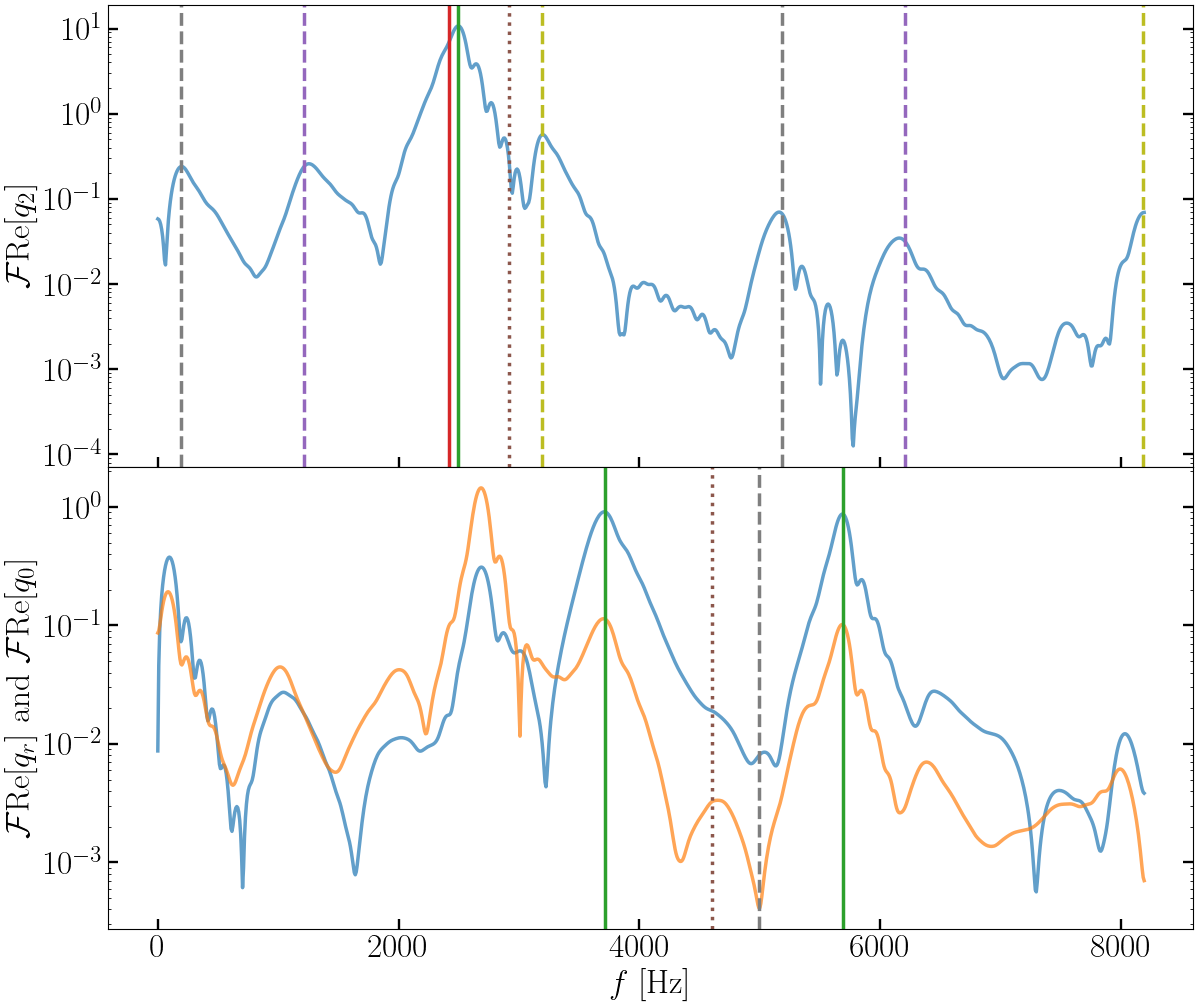

In [17]:
fig=plt.figure(figsize=(14, 12))

ax=fig.add_subplot(211)
ax.semilogy(freq, np.abs(Fq2), alpha=0.7, label=r'$m=2$')
# ax.semilogy(freq, np.abs(Fq0), alpha=0.7, label=r'$m=0$')
# ax.semilogy(freq, np.abs(Fqr), alpha=0.7, label=r'Radial')


# linear oscillation freq
ax.axvline(wf/tM1/2/np.pi, ls=':', color='C5')

# analytically predicted peak frequencies
ax.axvline(np.mean(wf_eff)/tM1/2/np.pi, color='C3')
ax.axvline(f2_data, color='C2')


# identifying all the nonlinear coupling peaks
ax.axvline(fr_data-f2_data, color='C4', ls='--')
ax.axvline(fr_data+f2_data, color='C4', ls='--')

ax.axvline(f0_data + f2_data, color='C7', ls='--')
ax.axvline(f0_data - f2_data, color='C7', ls='--')

ax.axvline(frsec_data - f2_data, color='C8', ls='--')
ax.axvline(frsec_data + f2_data, color='C8', ls='--')

ax.set_ylabel(r'$\mathcal{F}{\rm Re}[q_2]$')


ax=fig.add_subplot(212, sharex=ax)
ax.semilogy(freq, np.abs(Fqr), alpha=0.7, label=r'Radial')
ax.semilogy(freq, np.abs(Fq0), alpha=0.7, label=r'$m=0$')

ax.axvline(wr/tM1/2/np.pi, ls=':', color='C5')
ax.axvline(fr_data, color='C2')
ax.axvline(frsec_data, color='C2')

ax.axvline(2 * f2_data, ls='--', color='C7')

ax.set_ylabel(r'$\mathcal{F}{\rm Re}[q_r]$ and $\mathcal{F}{\rm Re}[q_0]$ ')
ax.set_xlabel(r'$f$ [Hz]')

fig.subplots_adjust(hspace=0)
plt.show()

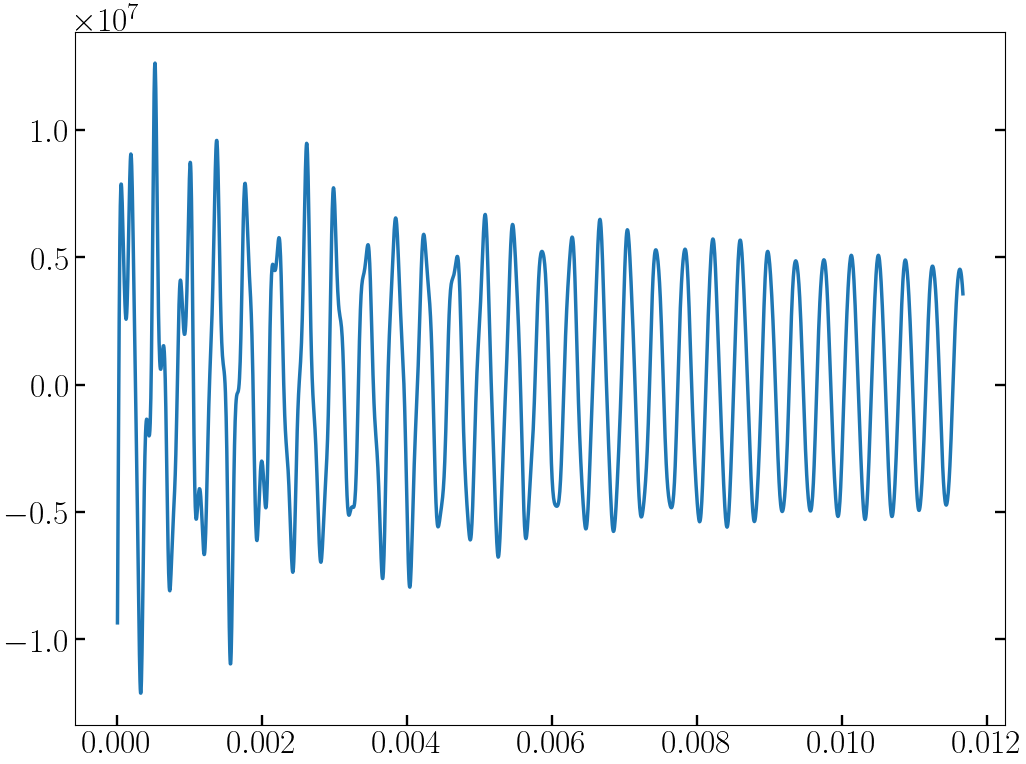

In [18]:
# GW strain from Q22

Q22 = Ia * q2 + J2 * q2 * qr + J2r * q2 * q0

Q22_vs_t = interp.CubicSpline(t_phy, Q22, extrapolate=False)
ddQ22 = Q22_vs_t(t_phy, 2)

fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(t_phy, np.real(ddQ22))
plt.show()

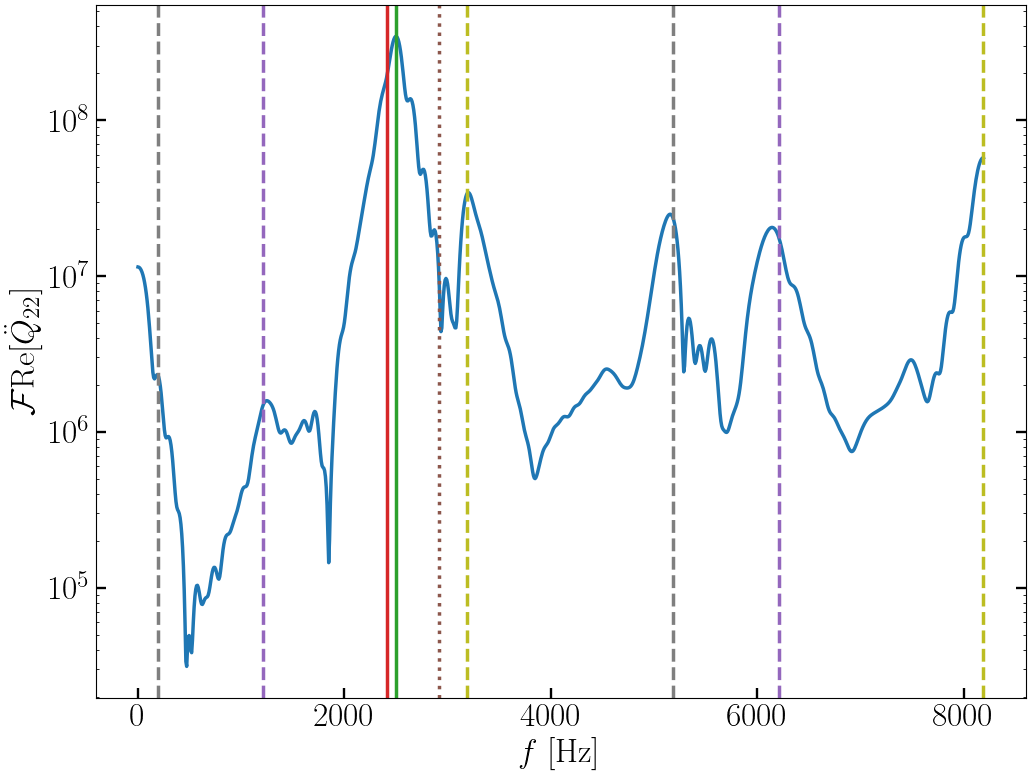

In [19]:
ReddQ22_vs_t = interp.CubicSpline(t_phy, win * sig.detrend(np.real(ddQ22)), extrapolate=False)
ReddQ22_grid = np.nan_to_num(ReddQ22_vs_t(tt_grid))

FddQ22 = np.fft.rfft(ReddQ22_grid)

fig=plt.figure()
ax=fig.add_subplot(111)
ax.semilogy(freq, np.abs(FddQ22))


# linear oscillation freq
ax.axvline(wf/tM1/2/np.pi, ls=':', color='C5')

# analytically predicted peak frequencies
ax.axvline(np.mean(wf_eff)/tM1/2/np.pi, color='C3')
ax.axvline(f2_data, color='C2')


# identifying all the nonlinear coupling peaks
ax.axvline(fr_data-f2_data, color='C4', ls='--')
ax.axvline(fr_data+f2_data, color='C4', ls='--')

ax.axvline(f0_data + f2_data, color='C7', ls='--')
ax.axvline(f0_data - f2_data, color='C7', ls='--')

ax.axvline(frsec_data - f2_data, color='C8', ls='--')
ax.axvline(frsec_data + f2_data, color='C8', ls='--')


ax.set_xlabel(r'$f$ [Hz]')
ax.set_ylabel(r'$\mathcal{F}{\rm Re}[\ddot{Q}_{22}]$')

plt.show()